In [2]:
from pathlib import Path
import os
import sys

from matplotlib import pyplot as plt
import scipy.io as sio
import mne
import numpy as np

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists()
)

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

%matplotlib qt

In [4]:
mat_data = sio.loadmat('data/database_reading_ft/Participant1.mat')
data = mat_data["Participant1"]

fs = 1024
ch_names = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 
            'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2', 'Rt', 'Lt']

# Os 19 primeiros são EEG, os 2 últimos são marcadores de movimento do dedo [cite: 15, 18, 59]
ch_types = ['eeg'] * 19 + ['misc'] * 2 

# Condições descritas no documento [cite: 84]
event_id = {'RightTap': 1, 'Resting': 2, 'LeftTap': 3}

n_canais, n_condicoes, n_trials = data.shape
n_amostras = 6144

In [5]:
total_trials = n_condicoes * n_trials
dados_mne = np.zeros((total_trials, n_canais, n_amostras))
eventos = np.zeros((total_trials, 3), dtype=int)

trial_idx = 0
for condicao in range(n_condicoes):
    for trial in range(n_trials):
        # Registrar o evento para o MNE saber qual trial é qual
        # Coluna 0: índice fictício de tempo, Coluna 2: ID da condição (1, 2 ou 3)
        eventos[trial_idx, 0] = trial_idx * n_amostras 
        eventos[trial_idx, 2] = condicao + 1 
        
        for canal in range(n_canais):
            # No scipy, os dados de um cell array vêm empacotados em arrays de objetos
            # Precisamos extrair o array unidimensional [0] e achatar (flatten)
            sinal = data[canal, condicao, trial].flatten()
            
            # Converter a escala para Volts (O MNE trabalha com Volts). 
            # O MATLAB provavelmente está em microvolts (µV) como mostrado na Figura 2 
            # Se os dados marcadores de movimento (Rt/Lt) forem apenas 0 e 1, não os alteramos.
            if canal < 19:
                sinal = sinal * 1e-6 
                
            dados_mne[trial_idx, canal, :] = sinal
            
        trial_idx += 1

In [6]:
info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=ch_types)

# Opcional: Adicionar posições padrão dos eletrodos (10-20) [cite: 57]
info.set_montage('standard_1020')

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, ...
 chs: 19 EEG, 2 misc
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 512.0 Hz
 meas_date: unspecified
 nchan: 21
 projs: []
 sfreq: 1024.0 Hz
>

In [7]:
epochs = mne.EpochsArray(dados_mne, info, events=eventos, event_id=event_id, tmin=-3.0)

Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated


In [8]:
target_sfreq = 400

In [9]:
epochs_cond = epochs["RightTap"].crop(tmin=0.0, tmax=1).pick_types(eeg=True, misc=False).resample(target_sfreq)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


In [10]:
data_np = epochs_cond.get_data()

In [37]:
# Bloco 2.5 — Otimizar Ordem do Modelo antes do MVARICA
from scot.var import VAR

print("Procurando a ordem ideal do modelo VAR (pode levar 1-2 minutos)...")
var_temp = VAR(model_order=1, delta=1.0)

# Testa ordens de 2 a 15
result = var_temp.optimize_order(data_np, min_p=40, max_p=60, n_jobs=3)
optimal_order = var_temp.p

print(f"✅ Ordem ótima encontrada: {optimal_order}")

# Plotar o Erro de Generalização (MSGE) por ordem
ordens, msge = zip(*result)
plt.figure(figsize=(6, 3))
plt.plot(ordens, msge, marker='o')
plt.axvline(optimal_order, color='r', linestyle='--', label=f'Ideal ({optimal_order})')
plt.title("Erro de Generalização por Ordem (MSGE)")
plt.xlabel("Ordem do Modelo (Lags)")
plt.ylabel("Erro")
plt.legend()
plt.show()

Procurando a ordem ideal do modelo VAR (pode levar 1-2 minutos)...
✅ Ordem ótima encontrada: 59


In [38]:
from scot.var import VAR
from scot.varica import mvarica
# 1. Configurar o modelo VAR base
# O parâmetro 'delta' no SCoT equivale ao 'l2_reg' (penalidade Ridge)
# Se quiser que o SCoT descubra o delta ótimo automaticamente, use optimize_var=True abaixo
var_base = VAR(
    model_order=optimal_order,   # Ajuste conforme necessário
    delta=0.01,       # Valor inicial da regularização L2
)
print("Iniciando MVARICA...")
# 2. Executar MVARICA
# varfit='ensemble' equivale ao 'avg-epochs' do mne-connectivity (multitrial)
mvarica_result = mvarica(
    x=data_np,
    var=var_base,
    reducedim='no_pca',   # Pode definir 0.99 para manter 99% da variância via PCA
    optimize_var=False,    # O SCoT vai otimizar o 'delta' (l2_reg) automaticamente!
    varfit='ensemble',    # Multitrial: ajusta 1 modelo para todas as épocas
)

Iniciando MVARICA...


In [39]:
var_eeg = mvarica_result.a
var_source = mvarica_result.b
print("=== MVARICA Concluído! ===")
print(f"Componentes mantidos após PCA: {var_source.coef.shape[0]}")
print(f"Delta (L2 reg) otimizado: {var_eeg.delta:.6f}")
print(f"Estabilidade do modelo (Espaço Fonte): {var_source.is_stable()}")
if not var_source.is_stable():
    print("⚠️ ATENÇÃO: O modelo AINDA está instável. Se for o caso, precisaremos aumentar a regularização L2 (delta) manualmente.")

=== MVARICA Concluído! ===
Componentes mantidos após PCA: 19
Delta (L2 reg) otimizado: 0.010000
Estabilidade do modelo (Espaço Fonte): True


In [40]:
import scipy.linalg
from scot.datatools import cat_trials

print("=== Avaliação de Qualidade do MVARICA ===")

# 1. Teste de Whiteness (Li-McLeod Portmanteau)
# O teste deve ser feito no modelo do espaço das fontes
n_times = data_np.shape[2]
h = int(np.sqrt(n_times))

p_val, q0, q = var_source.test_whiteness(h=h, repeats=200, get_q=True)
print(f"Whiteness Test p-value: {p_val:.4f}")
if p_val > 0.05:
    print("  ✅ Resíduos brancos (Modelo capturou bem a dinâmica temporal)")
else:
    print("  ❌ Resíduos correlacionados (Tente aumentar a ordem ou melhorar o detrending)")

# 2. Variância explicada / Estabilidade (Calculando o maior autovalor no SCoT)
m, mp = var_source.coef.shape
p_lags = mp // m

# Montando a companion matrix (matriz de transição) do SCoT
top_block = np.hstack([var_source.coef[:, i::p_lags] for i in range(p_lags)])
if p_lags > 1:
    im = np.eye(m)
    eye_block = im
    for i in range(p_lags - 2):
        eye_block = scipy.linalg.block_diag(im, eye_block)
    eye_block = np.hstack([eye_block, np.zeros((m * (p_lags - 1), m))])
    companion_matrix = np.vstack([top_block, eye_block])
else:
    companion_matrix = top_block

maior_autovalor = np.max(np.abs(np.linalg.eigvals(companion_matrix)))
print(f"\nMaior autovalor: {maior_autovalor:.4f} (Deve ser estritamente menor que 1.0)")

# 3. Visualizar distribuição dos resíduos da primeira fonte
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.hist(cat_trials(var_source.residuals)[0, :], bins=50, density=True)
plt.title("Distribuição dos Resíduos (Fonte 0)")
plt.show()

=== Avaliação de Qualidade do MVARICA ===
Whiteness Test p-value: 0.0000
  ❌ Resíduos correlacionados (Tente aumentar a ordem ou melhorar o detrending)

Maior autovalor: 0.9923 (Deve ser estritamente menor que 1.0)


In [45]:
from scot.connectivity import connectivity

# Calcular as matrizes de conectividade no espaço das fontes
nfft = 512
measures = connectivity(
    measure_names=['PDC', 'DTF', 'COH', 'ffPDC', 'ffDTF'],
    b=var_source.coef,
    c=var_source.rescov,
    nfft=nfft
)

# Criar eixo de frequências para os plots
freqs = np.linspace(0, target_sfreq / 2, nfft)

# Plotar o PDC (Partial Directed Coherence) entre a Fonte 0 e Fonte 1
source_A, source_B = 8, 10

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(freqs, measures['PDC'][source_A, source_B, :], label=f'Fonte {source_B} → Fonte {source_A}')
plt.plot(freqs, measures['PDC'][source_B, source_A, :], label=f'Fonte {source_A} → Fonte {source_B}')
plt.title('PDC (Conectividade Direcional)')
plt.xlabel('Frequência (Hz)')
plt.xlim(0, target_sfreq / 2)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freqs, measures['COH'][source_A, source_B, :])
plt.title(f'Coerência (Fonte {source_A} ↔ Fonte {source_B})')
plt.xlabel('Frequência (Hz)')
plt.xlim(0, target_sfreq / 2)

plt.tight_layout()
plt.show()

c:\Repositorios\msc-eeg-tms-pipeline\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Repositorios\msc-eeg-tms-pipeline\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Topografias espaciais das Fontes independentes:


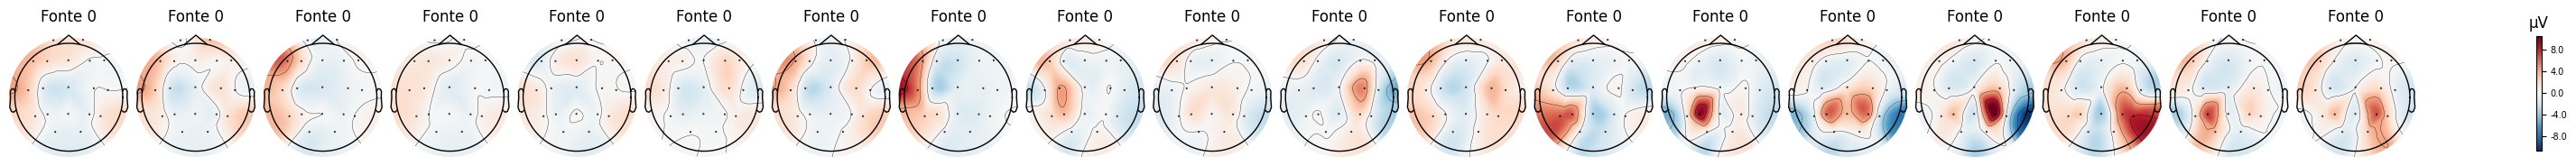

In [44]:
import mne

# A matriz 'mixing' mapeia Fontes -> Sensores
# Shape: (Canais, Fontes)
mixing_matrix = mvarica_result.mixing

# Criar EvokedArray artificial apenas para usar o plot_topomap do MNE
info = epochs_cond.info
evoked = mne.EvokedArray(mixing_matrix, info)

# Pegar os 5 primeiros "tempos" virtuais que correspondem às 5 primeiras fontes
num_fontes_plotar = min(5, mixing_matrix.shape[1])
tempos_virtuais = evoked.times[:num_fontes_plotar]

print("Topografias espaciais das Fontes independentes:")
# Plota os componentes
evoked.plot_topomap(
    times=evoked.times, 
    time_format='Fonte %d', 
    nrows=1
)

In [43]:
evoked.times

array([0.    , 0.0025, 0.005 , 0.0075, 0.01  , 0.0125, 0.015 , 0.0175,
       0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  , 0.0425, 0.045 ])

In [48]:
import seaborn as sns
from scot.connectivity import connectivity

# 1. Definir os nomes exatos dos canais na mesma ordem do seu dado
ch_names = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 
            'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']

# 2. Recalcular as medidas de conectividade, mas agora usando o var_eeg 
# (var_eeg = mvarica_result.a), que é o modelo focado nos CANAIS.
nfft = 512
measures_eeg = connectivity(
    measure_names=['PDC'],
    b=var_eeg.coef,
    c=var_eeg.rescov,
    nfft=nfft
)
freqs = np.linspace(0, target_sfreq / 2, nfft)

# 3. Filtrar para a Banda Motora (8 a 30 Hz)
freq_min = 8.0
freq_max = 30.0
idx_banda = np.where((freqs >= freq_min) & (freqs <= freq_max))[0]

pdc_completo_eeg = measures_eeg['PDC']
pdc_banda_eeg = pdc_completo_eeg[:, :, idx_banda]

# 4. Média na banda (Matriz 19x19) e zerar diagonal
pdc_matrix_eeg = np.mean(pdc_banda_eeg, axis=2)
np.fill_diagonal(pdc_matrix_eeg, 0)

# 5. Plotar a Matriz com os nomes reais dos eletrodos
plt.figure(figsize=(12, 10))

sns.heatmap(pdc_matrix_eeg, 
            xticklabels=ch_names, 
            yticklabels=ch_names,
            cmap="Reds",
            annot=False,
            cbar_kws={'label': 'PDC Médio (8-30 Hz)'})

plt.title("Matriz de Conectividade PDC entre CANAIS DE EEG (8-30 Hz)\nLeitura: Coluna (Origem) → Linha (Destino)")
plt.xlabel("Canal de Origem (Transmissor)")
plt.ylabel("Canal de Destino (Receptor)")
plt.tight_layout()
plt.show()